In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix
import itertools

2026-03-02 21:59:41.099965: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 21:59:41.101770: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 21:59:41.140373: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 21:59:41.286802: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 21:59:41.943983: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warnin

In [3]:
# carregando o dataset
cifar10 = tf.keras.datasets.cifar10

# carregando os dados
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# normalizando
X_train, X_test = X_train / 255, X_test / 255
# convertendo para um array
y_train, y_test = y_train.flatten(), y_test.flatten()

# formato dos dados
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)


In [4]:
# Número de classes de resposta
K = len(set(y_train))
print('Número de classes:', K)

Número de classes: 10


In [5]:
# criando a rede neural
i = Input(shape=X_train[0].shape)

x = Conv2D(32, (3,3), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(units=1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

In [6]:
# compilação
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [7]:
# treinamento
r = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 119s 74ms/step - accuracy: 0.4434 - loss: 1.7843 - val_accuracy: 0.6589 - val_loss: 0.9996
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 104s 66ms/step - accuracy: 0.6978 - loss: 0.8727 - val_accuracy: 0.7484 - val_loss: 0.7329
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 104s 67ms/step - accuracy: 0.7611 - loss: 0.6990 - val_accuracy: 0.7469 - val_loss: 0.7527
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 104s 67ms/step - accuracy: 0.8043 - loss: 0.5715 - val_accuracy: 0.7687 - val_loss: 0.6844
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - accuracy: 0.8350 - loss: 0.4789 - val_accuracy: 0.7625 - val_loss: 0.7281
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - accuracy: 0.8634 - loss: 0.4004 - val_accuracy: 0.8089 - val_loss: 0.6117
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - accuracy: 0.8859 - loss: 0.3278 - val_accuracy: 0.8003 - val_loss: 0.6359
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 

In [7]:
# Treinamento com data argumentation
# Se rodar imadiatamente depois do treinamento anterior, ele vai ser feito com os pesos do ultimo treinamento
# Por esse motivo, irei rodar os códigos de criação e compilação novamente antes de rodar esse código

# quantas partes serão enviadas por vez
batch_size = 32
# criando dados 
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)
# definindo os dados que serão usados como base
train_generator = data_generator.flow(X_train, y_train, batch_size)
# quantas passadas para ser considerada uma época
steps_per_epoch = X_train.shape[0] // batch_size
# treinamento
r = model.fit(train_generator, validation_data=(X_test, y_test), steps_per_epoch=steps_per_epoch, epochs=50)

Epoch 1/50
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 1:02:15 2s/step - accuracy: 0.1562 - loss: 3.2947

/home/liperasz/anaconda3/envs/Card-16/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 111s 69ms/step - accuracy: 0.4127 - loss: 1.8239 - val_accuracy: 0.5903 - val_loss: 1.1890
Epoch 2/50
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 1:34 61ms/step - accuracy: 0.5312 - loss: 1.2098

2026-03-02 22:01:54.481035: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/liperasz/anaconda3/envs/Card-16/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5312 - loss: 1.2098 - val_accuracy: 0.5875 - val_loss: 1.1872
Epoch 3/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 109s 70ms/step - accuracy: 0.6342 - loss: 1.0481 - val_accuracy: 0.6953 - val_loss: 0.8808
Epoch 4/50
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 1:42 65ms/step - accuracy: 0.6562 - loss: 0.9771

...

1562/1562 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 1.0000 - loss: 0.0970 - val_accuracy: 0.8664 - val_loss: 0.4133
Epoch 47/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.9003 - loss: 0.2827 - val_accuracy: 0.8493 - val_loss: 0.4672
Epoch 48/50
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 1:31 59ms/step - accuracy: 0.9062 - loss: 0.4270

2026-03-02 22:44:13.958795: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9062 - loss: 0.4270 - val_accuracy: 0.8510 - val_loss: 0.4667
Epoch 49/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - accuracy: 0.9001 - loss: 0.2901 - val_accuracy: 0.8718 - val_loss: 0.3973
Epoch 50/50
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 1:34 60ms/step - accuracy: 0.8438 - loss: 0.2497

2026-03-02 22:46:03.976602: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8438 - loss: 0.2497 - val_accuracy: 0.8726 - val_loss: 0.3961


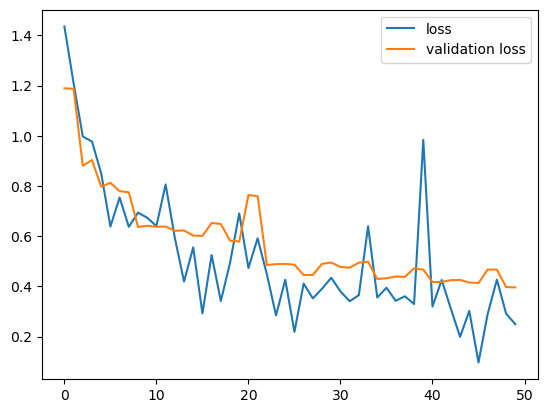

In [8]:
# grafico de comparação loss e validation loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='validation loss')
plt.legend()

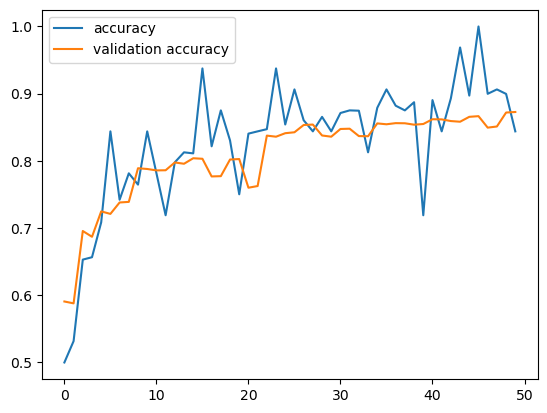

In [9]:
# grafico de comparação da accuracy e validation accuracy
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='validation accuracy')
plt.legend()

In [10]:
# função para mostrar a matriz de confusão
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):

    # a função mostra a matriz de confusao, se normalize for
    # colocado como True, os valores serão normalizados

    if normalize:
        # normaliza os valores
        cm = cm.astype('float') /cm.sum(axis=1)[:, np.newaxis]
        print('Normalized confusion matrix')

    else:
        print('confusion_matrix, without normalization')

    print(cm)

    # passando a matriz de confusão para mostrar    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    # titulo
    plt.title(title)
    # cores
    plt.colorbar()

    # define os nomes das classes
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # inserção do texto e formatação
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    # mostra as imagens e labels
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
confusion_matrix, without normalization
[[897   9  14   7   5   3   2  10  37  16]
 [  2 939   0   4   1   0   4   1   8  41]
 [ 43   2 780  27  35  44  32  29   4   4]
 [ 17   4  29 710  32 109  48  30  11  10]
 [  9   1  31  22 866  21  20  26   4   0]
 [  4   1  11  78  30 821  15  36   2   2]
 [  7   0  23  23   5   8 927   2   4   1]
 [  5   1   6  18  21  29   4 911   3   2]
 [ 27  10   4   4   0   1   0   0 944  10]
 [  9  36   4   3   0   0   2   4  11 931]]


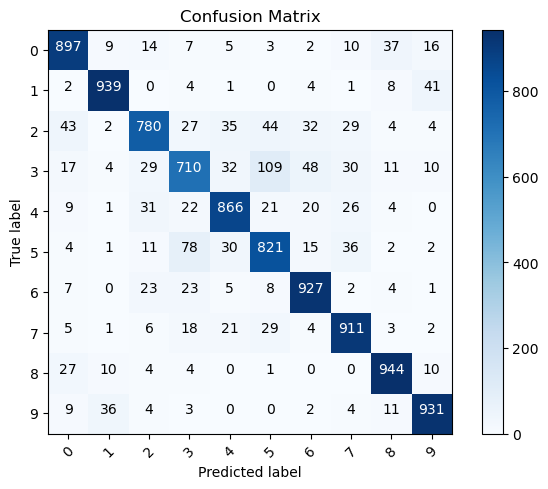

In [11]:
# testando a matriz de confusão
p_test = model.predict(X_test).argmax(axis=1) # fazendo previsões
cm = confusion_matrix(y_test, p_test) # matriz de confusão
plot_confusion_matrix(cm, list(range(10))) # função para mostrar matriz de confusão

In [12]:
# mapeando as labels
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

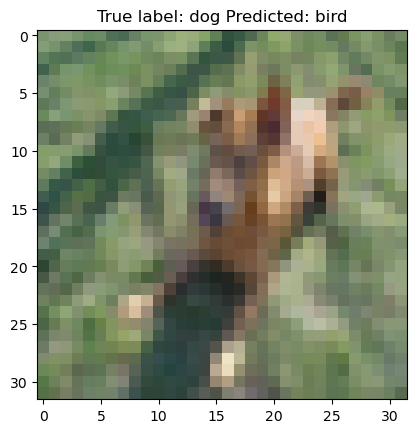

In [13]:
# Mostra exemplos errados
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(X_test[i], cmap='gray')
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]));

In [14]:
# como o modelo está grande, é bom utilizar um sumário para ver
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,189,888 (27.43 MB)

 Trainable params: 2,396,330 (9.14 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 4,792,662 (18.28 MB)